In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import numpy as np

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
df = pd.read_csv('../data/creditcard.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -

C:\Users\syahp\AppData\Local\Temp\ipykernel_18788\671987262.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort=True)



Distribusi Kelas (0: Normal, 1: Fraud):
Class
0    284315
1       492
Name: count, dtype: int64

Percentage - Normal: 99.83%, Fraud: 0.17%


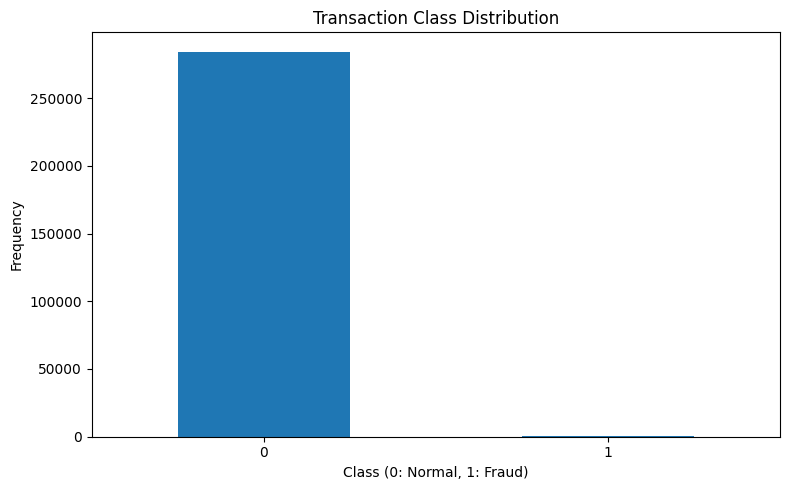

In [3]:
count_classes = pd.value_counts(df['Class'], sort=True)
print("\nDistribusi Kelas (0: Normal, 1: Fraud):")
print(count_classes)
print(f"\nPercentage - Normal: {count_classes[0]/len(df)*100:.2f}%, Fraud: {count_classes[1]/len(df)*100:.2f}%")

count_classes.plot(kind='bar', rot=0, figsize=(8, 5))
plt.title("Transaction Class Distribution")
plt.xlabel("Class (0: Normal, 1: Fraud)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [4]:
print("--- Data Preprocessing ---")
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features: {list(X.columns)}")

--- Data Preprocessing ---
Features shape: (284807, 30)
Target shape: (284807,)
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [5]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outliers_mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"\nJumlah data asli: {len(X)}")
print(f"Jumlah outliers terdeteksi: {len(X) - outliers_mask.sum()}")
print(f"Jumlah data setelah outlier removal: {outliers_mask.sum()}")
print(f"Persentase data dihapus: {(len(X) - outliers_mask.sum())/len(X)*100:.2f}%")

X_clean = X[outliers_mask]
y_clean = y[outliers_mask]


Jumlah data asli: 284807
Jumlah outliers terdeteksi: 138473
Jumlah data setelah outlier removal: 146334
Persentase data dihapus: 48.62%


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_clean
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts())


Training set size: 117067
Test set size: 29267

Training set class distribution:
Class
0    117055
1        12
Name: count, dtype: int64

Test set class distribution:
Class
0    29264
1        3
Name: count, dtype: int64


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data scaled successfully")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"\nScaled data statistics (training set):")
print(f"Mean: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Std: {X_train_scaled.std(axis=0)[:5]}")

✅ Data scaled successfully
X_train_scaled shape: (117067, 30)
X_test_scaled shape: (29267, 30)

Scaled data statistics (training set):
Mean: [-5.97242649e-17  4.54001526e-17 -6.06953912e-18 -7.28344694e-18
  1.89369620e-17]
Std: [1. 1. 1. 1. 1.]


In [8]:
print("🔄 Training Random Forest Model...")
model = RandomForestClassifier(
    n_estimators=200,      # Jumlah trees
    max_depth=15,          # Kedalaman maksimal tree
    min_samples_split=10,  # Minimal sample untuk split
    min_samples_leaf=5,    # Minimal sample di leaf node
    random_state=42, 
    class_weight='balanced',  # Handle imbalance
    n_jobs=-1              # Gunakan semua CPU cores
)

model.fit(X_train_scaled, y_train)
print("✅ Model training completed!")
print(f"Training accuracy: {model.score(X_train_scaled, y_train):.4f}")

🔄 Training Random Forest Model...
✅ Model training completed!
Training accuracy: 1.0000


In [9]:
print("--- Cross-Validation Evaluation ---")
cv_scores = cross_val_score(
    model, X_train_scaled, y_train, 
    cv=5, 
    scoring='roc_auc'
)

print(f"ROC-AUC CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Std CV Score: {cv_scores.std():.4f}")
print(f"Min CV Score: {cv_scores.min():.4f}")
print(f"Max CV Score: {cv_scores.max():.4f}")

--- Cross-Validation Evaluation ---
ROC-AUC CV Scores: [0.48133356 0.65264192 0.96621246 0.73776216 0.98803981]
Mean CV Score: 0.7652
Std CV Score: 0.1919
Min CV Score: 0.4813
Max CV Score: 0.9880


In [10]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("✅ Predictions generated")
print(f"Predictions shape: {y_pred.shape}")
print(f"Prediction probabilities shape: {y_pred_proba.shape}")

✅ Predictions generated
Predictions shape: (29267,)
Prediction probabilities shape: (29267,)


In [11]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     29264
       Fraud       0.00      0.00      0.00         3

    accuracy                           1.00     29267
   macro avg       0.50      0.50      0.50     29267
weighted avg       1.00      1.00      1.00     29267



d:\tugas_akhir\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\tugas_akhir\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\tugas_akhir\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score (Test Set): {roc_auc:.4f}")

ROC-AUC Score (Test Set): 0.4690


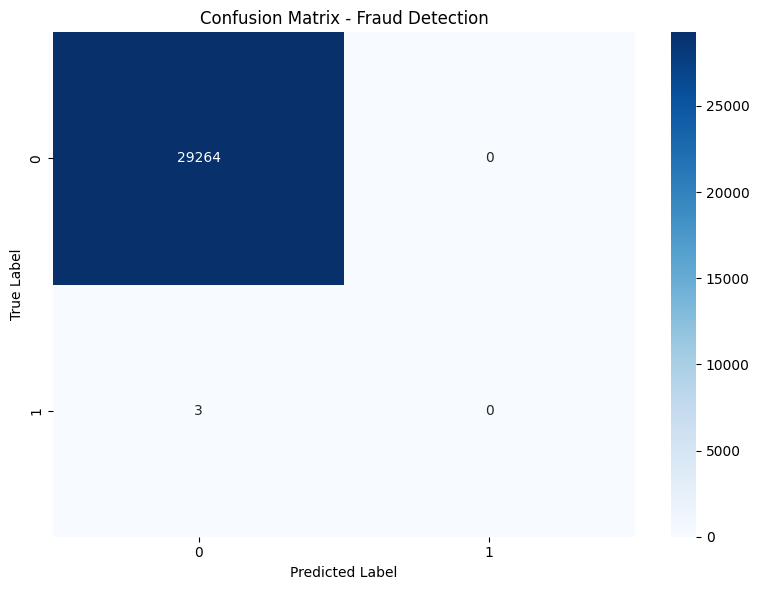


Confusion Matrix:
True Negatives (TN): 29264
False Positives (FP): 0
False Negatives (FN): 3
True Positives (TP): 0


In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title("Confusion Matrix - Fraud Detection")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(f"True Negatives (TN): {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP): {cm[1, 1]}")

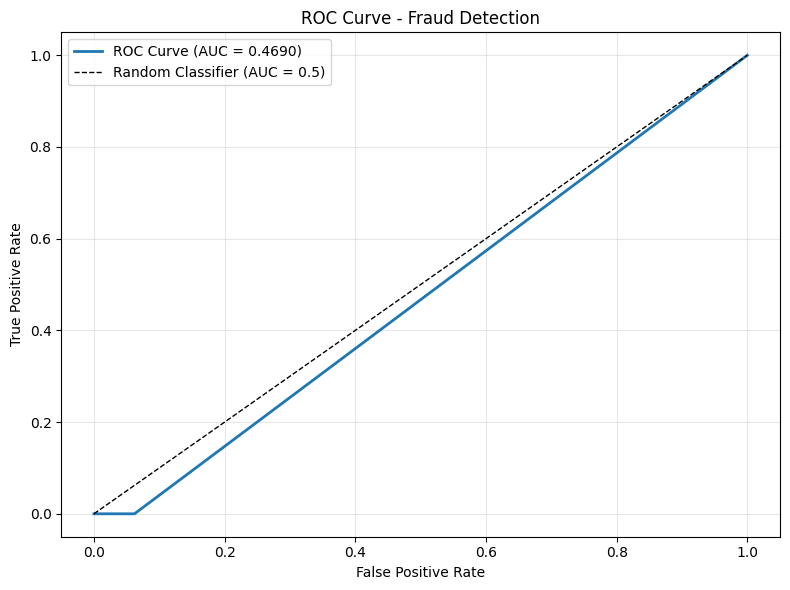

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Fraud Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(model, '../models/fraud_model_improved.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Model saved: ../models/fraud_model_improved.pkl")
print("✅ Scaler saved: ../models/scaler.pkl")

✅ Model saved: ../models/fraud_model_improved.pkl
✅ Scaler saved: ../models/scaler.pkl


In [16]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\n--- Top 20 Most Important Features ---")
print(feature_importance.head(20))


--- Top 20 Most Important Features ---
   feature  importance
0      V14    0.106769
1       V2    0.100080
2       V4    0.088667
3      V16    0.067756
4      V17    0.061261
5       V5    0.057914
6      V19    0.050847
7       V7    0.047574
8   Amount    0.042258
9      V18    0.038448
10     V13    0.030959
11      V1    0.029941
12     V10    0.023990
13     V23    0.023240
14     V12    0.020918
15      V8    0.020316
16     V15    0.019938
17     V20    0.016806
18     V28    0.016580
19      V3    0.016546


C:\Users\syahp\AppData\Local\Temp\ipykernel_18788\4225625340.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')


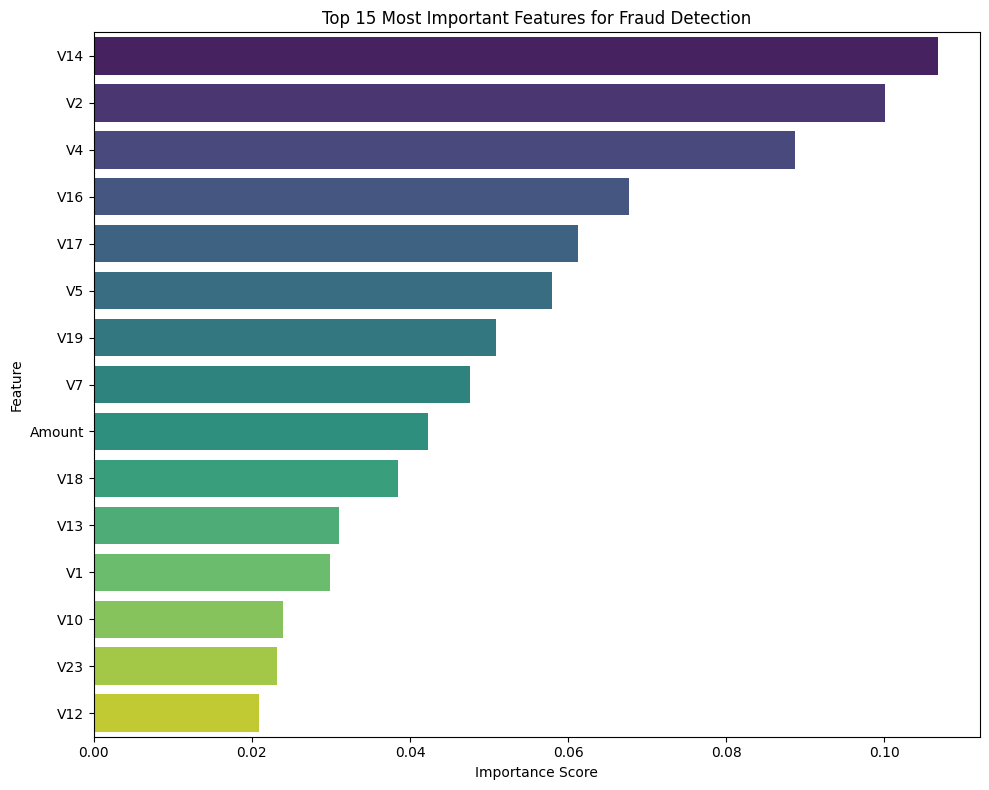

In [17]:
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title("Top 15 Most Important Features for Fraud Detection")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()